# Entangler ablation in Daskin's parameterized quantum circuit

**Base paper:** A. Daskin, *Quantum simulations based on parameterized circuit of
an antisymmetric matrix*, [arXiv:2505.01023](https://arxiv.org/abs/2505.01023).

The base paper builds a circuit
$$U(\theta) \;=\; W^{\dagger}\,\Lambda\,W, \qquad W = F\,D\,P$$
that is trained so that $\log U(\theta) \approx A$ for a target real
antisymmetric $A$. Its permutation layer $P$ entangles with **parameterized
controlled-$R_y$** gates. This notebook ablates that entangler along two axes,
which happens to give a **parameter-matched $2\times2$ factorial**:

|                   | arity 2            | arity 3    | total params |
|-------------------|--------------------|------------|--------------|
| **parameterized** | `CRy` (base paper) | `CCRy`     | 17 |
| **fixed**         | `CNOT`, `CZ`       | `CCX`, `CCZ` | 15 |

Every arm sees the **same target matrix** in each trial, so all comparisons are
paired. Each (trial, arm) is optimized from `N_RESTARTS` independent random
initializations and the best kept: Daskin reports that failures in his own runs
are mostly local minima *"which can be prevented in some cases by restarting
optimization by using different initial parameters"* (sec. 3.3).

**Run the notebook top to bottom.** Section 6 must pass before any number in
sections 7-9 means anything. Section 7 takes roughly 12 minutes.

---
### Three things this notebook does differently from a naive implementation

1. **The matrix logarithm is closed-form, not `scipy.linalg.logm`.** Because
   $W^{\dagger}\Lambda W$ *is* an eigendecomposition, $\log U$ can be read off
   the $\Lambda$ angles (Daskin sec. 3.2). `logm` takes the principal branch,
   which is discontinuous whenever an eigenphase crosses $\pm\pi$ — and
   `L-BFGS-B` estimates its gradient by finite differences straight across that
   discontinuity. The closed form is exact, smooth, and lets the circuit
   represent eigenvalues of $A$ with modulus above $\pi$.
2. **$\Lambda$ takes cotangents of its parameters** (Daskin sec. 3.1 item 4),
   because $\mathrm{eig}(G) = -i\cot\!\big((2k{+}1)\pi/2N\big)$. Feeding the raw
   angle instead changes which spectra the ansatz can reach.
3. **Parameters are bound by object, never by position.**
   `list(circuit.parameters)` is sorted **alphabetically by name**, not in build
   order, so slicing an optimizer's `x` vector positionally silently binds the
   wrong layer.

## 0. Setup

In [1]:
import json, time, itertools
import numpy as np
from scipy.optimize import minimize
from scipy.linalg import expm
from scipy import stats

from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import (Operator, Statevector, DensityMatrix,
                                 partial_trace, purity)

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
%matplotlib inline

# ---- experiment configuration -------------------------------------------
N_QUBITS   = 3
N_TRIALS   = 50      # paired trials (one random target matrix each)
N_RESTARTS = 3       # random initializations per (trial, arm); best is kept
MAX_ITER   = 300
SEED       = 20260919

# cot(alpha) has poles at 0 and pi; keep the Lambda angles clear of them.
ALPHA_LO, ALPHA_HI = 0.05, np.pi - 0.05

print("qiskit", __import__("qiskit").__version__,
      "| numpy", np.__version__, "| scipy", __import__("scipy").__version__)

qiskit 2.5.2 | numpy 2.4.4 | scipy 1.17.1


## 1. The circuit

`P` follows Daskin sec. 3.1 item 1 and Fig. 2(a): *"one layer of single
rotations, followed by a group of controlled rotations (entangling group of two
qubits), then another layer of single gates, and finally another controlled
rotations entangling previously entangled group of twos."* The **entangler** is
the component being ablated; everything else is identical across arms.

In [2]:
# --------------------------------------------------------------------------
# Entangler registry.  'param' = does the entangler itself carry a trainable
# angle.  'arity' = qubits touched per application.
# --------------------------------------------------------------------------
ENTANGLERS = {
    "cry":  dict(arity=2, param=True,  label="CRy",  base=True),
    "cnot": dict(arity=2, param=False, label="CNOT", base=False),
    "cz":   dict(arity=2, param=False, label="CZ",   base=False),
    "ccry": dict(arity=3, param=True,  label="CCRy", base=False),
    "ccx":  dict(arity=3, param=False, label="CCX",  base=False),
    "ccz":  dict(arity=3, param=False, label="CCZ",  base=False),
}
VARIANTS = list(ENTANGLERS)


def entangler_sites(n, arity, rnd):
    """Qubit tuples touched by entangling round `rnd` (0 or 1).

    arity 2 -- round 0: (0,1),(2,3),...   round 1: (1,2),(3,4),...
    arity 3 -- round 0: (0,1,2),(3,4,5).. round 1: same triples cyclically
               shifted by one, so round 1 is a genuinely different operation
               rather than a repeat (relevant for CCX; CCZ is permutation
               symmetric so for n=3 its two rounds differ only via the Ry
               layer between them).
    """
    if arity == 2:
        start = 0 if rnd == 0 else 1
        return [(i, i + 1) for i in range(start, n - 1, 2)]
    sites = []
    if rnd == 0:
        for i in range(0, n - 2, 3):
            sites.append((i, i + 1, i + 2))
    else:
        for i in range(0, n - 2, 3):
            a, b, c = i, i + 1, i + 2
            sites.append((b, c, a))          # cyclic shift
    return sites


def build_P(n, variant):
    """Permutation layer, Daskin's structure, with `variant` as the entangler."""
    spec = ENTANGLERS[variant]
    arity = spec["arity"]
    rounds = [entangler_sites(n, arity, 0), entangler_sites(n, arity, 1)]
    n_ent = sum(len(r) for r in rounds) if spec["param"] else 0

    qc = QuantumCircuit(n)
    ry = ParameterVector(f"ry_{variant}", 2 * n)
    ent = ParameterVector(f"ent_{variant}", n_ent)
    k = 0
    e = 0

    for rnd in range(2):
        for q in range(n):                       # single-qubit Ry layer
            qc.ry(ry[k], q); k += 1
        for site in rounds[rnd]:                 # entangling round
            if variant == "cry":
                qc.cry(ent[e], site[0], site[1]); e += 1
            elif variant == "cnot":
                qc.cx(site[0], site[1])
            elif variant == "cz":
                qc.cz(site[0], site[1])
            elif variant == "ccry":
                g = QuantumCircuit(1, name="ry")
                g.ry(ent[e], 0); e += 1
                qc.append(g.to_gate().control(2), list(site))
            elif variant == "ccx":
                qc.ccx(*site)
            elif variant == "ccz":
                qc.ccz(*site)
    return qc

In [3]:
def build_W(n, variant):
    """W = F D P as a circuit (P applied first).  U = W^dag Lambda W."""
    qcP = build_P(n, variant)

    qcD = QuantumCircuit(n)
    pD = ParameterVector(f"d_{variant}", n)
    for q in range(n):
        qcD.rz(pD[q], q)

    qcF = QuantumCircuit(n)
    pF = ParameterVector(f"f_{variant}", n * (n - 1) // 2)
    i2 = 0
    for i in range(n):
        qcF.h(i)
        for j in range(i + 1, n):
            qcF.cp(pF[i2], j, i); i2 += 1

    W = qcP.compose(qcD).compose(qcF)
    return W, qcP

## 2. $\Lambda$, the closed-form logarithm, and the loss

$R_z(t)=\mathrm{diag}(e^{-it/2},e^{+it/2})$, so with
$\Lambda = R_z(\cot\alpha_0)\otimes\cdots\otimes R_z(\cot\alpha_{n-1})$ the basis
state $k$ picks up
$$\varphi_k \;=\; \sum_j s_{jk}\,\frac{\cot\alpha_j}{2},
\qquad s_{jk} = \begin{cases}-1 & \text{bit } j \text{ of } k = 0\\ +1 & \text{else}\end{cases}$$
and then $\log U = W^{\dagger}\,\big(i\,\mathrm{diag}\,\varphi\big)\,W$ exactly.

The phases are returned **unwrapped**: $e^{i\varphi}$ is unaffected, but keeping
them unwrapped is what makes $\log U$ a smooth function of the parameters.

The loss is normalized by $\|A\|_F$ so trials with different target scales are
comparable. This fixes a useful reference point: $U=I \Rightarrow \log U = 0
\Rightarrow \mathcal{L} = 1$ **exactly**, so a circuit doing nothing scores 1.000
and every number below should be read against that.

**The residual is complex, and the loss uses all of it.** $\log U$ is
anti-Hermitian, so its real part is antisymmetric and its imaginary part
symmetric; for a real target,
$\|\log U - A\|_F^2 = \|\mathrm{Re}\log U - A\|_F^2 + \|\mathrm{Im}\log U\|_F^2$.
An earlier version of this benchmark fitted only the real part, which left the
imaginary part free and made the losses look 0.13 to 0.19 better than they are.
The benchmark stores both parts at every optimum so this stays checkable.

In [4]:
def lambda_phases(alphas, n):
    """Diagonal phases of Lambda = Rz(cot a_0) (x) ... (x) Rz(cot a_{n-1}).

    Rz(t) = diag(e^{-it/2}, e^{+it/2}), so basis state k picks up
        phi_k = sum_j s_jk * cot(a_j) / 2,   s = -1 if bit j of k is 0 else +1.
    Qiskit orders qubit 0 as the least significant bit.

    These phases are returned UNWRAPPED.  exp(i*phi) is unaffected, but keeping
    them unwrapped makes log(U) a smooth function of the parameters and lets the
    circuit represent eigenvalues of A with magnitude above pi, which the
    principal branch of scipy.linalg.logm cannot.
    """
    t = 1.0 / np.tan(alphas)                                  # cotangent
    idx = np.arange(2 ** n)
    bits = (idx[:, None] >> np.arange(n)[None, :]) & 1        # qubit 0 = LSB
    return ((2 * bits - 1) * (t[None, :] / 2.0)).sum(axis=1)


def log_U(Wmat, phi):
    """log(U) for U = W^dag diag(e^{i phi}) W.  Exact; anti-Hermitian by form."""
    return Wmat.conj().T @ (1j * phi[:, None] * Wmat)


def unitary_from(Wmat, phi):
    return Wmat.conj().T @ (np.exp(1j * phi)[:, None] * Wmat)

In [5]:
def gen_A(N, rng):
    """Random real antisymmetric NxN, off-diagonals uniform on [-1, 1]."""
    A = np.zeros((N, N))
    iu = np.triu_indices(N, 1)
    A[iu] = rng.uniform(-1, 1, len(iu[0]))
    return A - A.T


def normalized_loss(logu, A, normA):
    """||log U - A||_F / ||A||_F.   U = I  =>  loss = 1 exactly."""
    return float(np.linalg.norm(logu - A, "fro") / normA)

## 3. Entanglement measures

Two measures, because one of them is routinely misread.

**Average single-qubit purity** $\overline{\mathrm{Tr}\rho_i^2}$. For a *pure*
global state this equals 1 for every qubit **iff** the state is a product state,
so it detects multipartite entanglement perfectly well — GHZ gives $0.5$, W gives
$5/9$. It is the Meyer-Wallach global entanglement measure up to $Q=2(1-P)$. It
is *not* a bipartite-only proxy.

**Residual three-tangle** $\tau_{ABC}$ (Coffman-Kundu-Wootters), a genuine
tripartite measure, permutation invariant: GHZ $\to 1$, W $\to 0$, product
$\to 0$, Bell$\otimes|0\rangle \to 0$. Section 6 checks all of these.

In [6]:
def avg_single_qubit_purity(state, n):
    """Mean Tr(rho_i^2).  For a PURE global state this is 1 for every qubit iff
    the state is a product state, so it detects multipartite entanglement too
    (GHZ -> 0.5, W -> 5/9).  It is the Meyer-Wallach measure up to Q = 2(1-P)."""
    dm = DensityMatrix(state)
    return float(np.mean([
        purity(partial_trace(dm, [i for i in range(n) if i != q])).real
        for q in range(n)
    ]))


def three_tangle(psi):
    """Coffman-Kundu-Wootters residual tangle tau_ABC for 3 qubits.
    Genuine tripartite measure, invariant under qubit permutation.
    GHZ -> 1, W -> 0, product -> 0, Bell (x) |0> -> 0."""
    a = np.asarray(psi).reshape(2, 2, 2)
    d1 = (a[0,0,0]**2*a[1,1,1]**2 + a[0,0,1]**2*a[1,1,0]**2
        + a[0,1,0]**2*a[1,0,1]**2 + a[1,0,0]**2*a[0,1,1]**2)
    d2 = (a[0,0,0]*a[1,1,1]*a[0,1,1]*a[1,0,0] + a[0,0,0]*a[1,1,1]*a[1,0,1]*a[0,1,0]
        + a[0,0,0]*a[1,1,1]*a[1,1,0]*a[0,0,1] + a[0,1,1]*a[1,0,0]*a[1,0,1]*a[0,1,0]
        + a[0,1,1]*a[1,0,0]*a[1,1,0]*a[0,0,1] + a[1,0,1]*a[0,1,0]*a[1,1,0]*a[0,0,1])
    d3 = (a[0,0,0]*a[1,1,0]*a[1,0,1]*a[0,1,1] + a[1,1,1]*a[0,0,1]*a[0,1,0]*a[1,0,0])
    return float(np.abs(4 * (d1 - 2 * d2 + 4 * d3)))

## 4. Hardware cost

Accuracy alone is not the NISQ question. A three-qubit entangler is not free: it
transpiles to several CNOTs. These counts turn the results into an
accuracy-per-cost comparison in section 9.

In [7]:
def hardware_cost(n, variant, basis=("rz", "sx", "x", "cx")):
    """Transpiled two-qubit gate count and depth for the FULL circuit
    U = W^dag Lambda W, on a CNOT-based basis."""
    W, _ = build_W(n, variant)
    qcL = QuantumCircuit(n)
    pL = ParameterVector(f"lam_{variant}", n)
    for q in range(n):
        qcL.rz(pL[q], q)
    full = W.inverse().compose(qcL).compose(W)
    rng = np.random.default_rng(0)
    pars = list(full.parameters)
    bound = full.assign_parameters(
        dict(zip(pars, rng.uniform(0.2, 2.9, len(pars)))))
    tq = transpile(bound, basis_gates=list(basis), optimization_level=2)
    return dict(two_qubit=tq.count_ops().get("cx", 0), depth=tq.depth())


def param_counts(n, variant):
    W, qcP = build_W(n, variant)
    return dict(P=len(qcP.parameters), W=len(W.parameters),
                total=len(W.parameters) + n)   # + n Lambda angles

## 5. Fast evaluator

`Operator()` costs about 1.1 ms per parameter binding. With finite-difference
gradients over ~17 parameters that cost dominates the whole experiment, so the
same matrix is built directly in numpy. Section 6 asserts the two agree to
machine precision — the fast path is only worth having if it is provably the
same circuit.

In [8]:
X = np.array([[0, 1], [1, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)

def Ry(t):
    c, s = np.cos(t / 2), np.sin(t / 2)
    return np.array([[c, -s], [s, c]], dtype=complex)

def ctrl_matrix(n, U2, controls, target):
    """2^n x 2^n matrix for U2 on `target`, conditioned on all `controls` = 1."""
    N = 2 ** n
    M = np.zeros((N, N), dtype=complex)
    for k in range(N):
        if all((k >> c) & 1 for c in controls):
            b = (k >> target) & 1
            for bp in (0, 1):
                kp = (k & ~(1 << target)) | (bp << target)
                M[kp, k] = U2[bp, b]
        else:
            M[k, k] = 1.0
    return M

def rz_layer(n, angles):
    """Kronecker product of Rz(angles[q]) over qubits: diagonal."""
    idx = np.arange(2 ** n)
    bits = (idx[:, None] >> np.arange(n)[None, :]) & 1
    return np.exp(1j * ((2 * bits - 1) * (np.asarray(angles)[None, :] / 2.0)).sum(1))

def cp_diag(n, lam, c, t):
    idx = np.arange(2 ** n)
    both = (((idx >> c) & 1) & ((idx >> t) & 1)).astype(float)
    return np.exp(1j * lam * both)


class FastW:
    """Pre-resolved gate program for W = F D P of a given arity/variant.

    Call .matrix(x) with the parameter vector ordered as
        [ry (2n), ent (n_ent), d (n), f (n(n-1)/2)]
    and .lambda_slice / .n_params describe the layout.
    """
    def __init__(self, n, variant):
        self.n, self.variant = n, variant
        spec = ENTANGLERS[variant]
        self.arity, self.param_ent = spec["arity"], spec["param"]
        self.rounds = [entangler_sites(n, self.arity, r) for r in range(2)]
        self.n_ent = sum(len(r) for r in self.rounds) if self.param_ent else 0
        self.n_ry = 2 * n
        self.n_d = n
        self.n_f = n * (n - 1) // 2
        self.n_W = self.n_ry + self.n_ent + self.n_d + self.n_f
        self.n_params = self.n_W + n          # + Lambda angles

        # static (unparameterized) entangler matrices, precomputed once
        self._static = []
        for r in range(2):
            layer = []
            for site in self.rounds[r]:
                if variant == "cnot":
                    layer.append(ctrl_matrix(n, X, [site[0]], site[1]))
                elif variant == "cz":
                    layer.append(ctrl_matrix(n, Z, [site[0]], site[1]))
                elif variant == "ccx":
                    layer.append(ctrl_matrix(n, X, [site[0], site[1]], site[2]))
                elif variant == "ccz":
                    layer.append(ctrl_matrix(n, Z, [site[0], site[1]], site[2]))
            self._static.append(layer)

        # F layer: H on each qubit then controlled phases (matches build_W)
        self._H = [ctrl_matrix(n, H, [], q) for q in range(n)]
        self._f_pairs = [(j, i) for i in range(n) for j in range(i + 1, n)]

    # -- slices ----------------------------------------------------------
    def sl_ry(self):  return slice(0, self.n_ry)
    def sl_ent(self): return slice(self.n_ry, self.n_ry + self.n_ent)
    def sl_d(self):   return slice(self.n_ry + self.n_ent,
                                   self.n_ry + self.n_ent + self.n_d)
    def sl_f(self):   return slice(self.n_ry + self.n_ent + self.n_d, self.n_W)
    def sl_lam(self): return slice(self.n_W, self.n_params)

    # -- matrices --------------------------------------------------------
    def P_matrix(self, x):
        n = self.n
        ry, ent = x[self.sl_ry()], x[self.sl_ent()]
        M = np.eye(2 ** n, dtype=complex)
        k = e = 0
        for r in range(2):
            for q in range(n):
                M = ctrl_matrix(n, Ry(ry[k]), [], q) @ M; k += 1
            if self.param_ent:
                for site in self.rounds[r]:
                    ctrls = list(site[:-1])
                    M = ctrl_matrix(n, Ry(ent[e]), ctrls, site[-1]) @ M; e += 1
            else:
                for G in self._static[r]:
                    M = G @ M
        return M

    def matrix(self, x):
        """W = F D P."""
        n = self.n
        M = self.P_matrix(x)
        M = rz_layer(n, x[self.sl_d()])[:, None] * M          # D
        f = x[self.sl_f()]
        i2 = 0
        for q in range(n):                                     # F
            M = self._H[q] @ M
            for (j, i) in [p for p in self._f_pairs if p[1] == q]:
                M = cp_diag(n, f[i2], j, i)[:, None] * M; i2 += 1
        return M

## 6. Correctness checks

**Nothing below section 6 is meaningful unless these pass.** In particular check
(6) is the load-bearing one: it confirms the reconstructed circuit is really
Daskin's, by reproducing the gate count he states for $n_q=3$ — *"a 3-qubit
circuit has approximately parameterized 17 gates that try to predict a
64-element unitary matrix."*

In [9]:
import numpy as np
from scipy.linalg import expm
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Operator, Statevector

n = N_QUBITS
N = 2 ** n
rng = np.random.default_rng(0)
fails = []

def chk(name, ok, detail=""):
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}  {detail}")
    if not ok:
        fails.append(name)

print("\n(1) three-tangle against states with known values")
r2, r3 = 1/np.sqrt(2), 1/np.sqrt(3)
known = {
    "GHZ":            (np.array([r2,0,0,0,0,0,0,r2]), 1.0),
    "W":              (np.array([0,r3,r3,0,r3,0,0,0]), 0.0),
    "product |+++>":  (np.ones(8)/np.sqrt(8), 0.0),
    "Bell(x)|0>":     (np.array([r2,0,0,0,0,0,r2,0]), 0.0),
}
for k, (v, want) in known.items():
    got = three_tangle(v)
    chk(f"tau({k}) = {want}", abs(got - want) < 1e-10, f"got {got:.2e}")

print("\n(2) average single-qubit purity against known states")
for k, want in [("GHZ", 0.5), ("W", 5/9), ("product |+++>", 1.0)]:
    got = avg_single_qubit_purity(Statevector(known[k][0]), 3)
    chk(f"purity({k}) = {want:.4f}", abs(got - want) < 1e-10, f"got {got:.6f}")

print("\n(3) analytic log is an exact logarithm:  expm(log_U) == U")
for v in VARIANTS:
    W, _ = build_W(n, v)
    pw = list(W.parameters)
    Wm = Operator(W.assign_parameters(
        dict(zip(pw, rng.uniform(0.15, 2.9, len(pw)))))).data
    alphas = rng.uniform(0.35, np.pi - 0.35, n)
    phi = lambda_phases(alphas, n)
    U = unitary_from(Wm, phi)
    L = log_U(Wm, phi)
    chk(f"{v:5s} expm(log U) == U", np.linalg.norm(expm(L) - U, "fro") < 1e-9,
        f"err {np.linalg.norm(expm(L)-U,'fro'):.2e}")
    chk(f"{v:5s} log U anti-Hermitian",
        np.linalg.norm(L + L.conj().T, "fro") < 1e-10,
        f"err {np.linalg.norm(L+L.conj().T,'fro'):.2e}")
    chk(f"{v:5s} U unitary",
        np.linalg.norm(U.conj().T @ U - np.eye(N), "fro") < 1e-10)

print("\n(4) analytic Lambda phases match the Qiskit-built Lambda circuit")
alphas = rng.uniform(0.35, np.pi - 0.35, n)
qcL = QuantumCircuit(n)
for q in range(n):
    qcL.rz(1.0 / np.tan(alphas[q]), q)
diag_qiskit = np.diag(Operator(qcL).data)
phi = lambda_phases(alphas, n)
chk("Lambda diagonal matches", np.allclose(np.exp(1j * phi), diag_qiskit, atol=1e-10),
    f"max|diff| {np.max(np.abs(np.exp(1j*phi) - diag_qiskit)):.2e}")

print("\n(5) identity baseline: U = I gives normalized loss exactly 1")
A = gen_A(N, rng)
chk("loss(U=I) == 1", abs(normalized_loss(np.zeros_like(A), A,
                                          np.linalg.norm(A, 'fro')) - 1.0) < 1e-12)

print("\n(6) base arm reproduces Daskin's stated gate count for n_q = 3")
pc = param_counts(n, "cry")
chk("CRy arm has 17 parameterized gates", pc["total"] == 17,
    f"P={pc['P']} + D,F={pc['W']-pc['P']} + Lambda={n} -> {pc['total']} "
    f"(paper: 'approximately parameterized 17 gates')")

print("\n(7) fixed-entangler arms carry strictly fewer parameters than the base")
base = param_counts(n, "cry")["total"]
for v in VARIANTS:
    t = param_counts(n, v)["total"]
    rel = "==" if t == base else ("<" if t < base else ">")
    ok = (t == base) if ENTANGLERS[v]["param"] and ENTANGLERS[v]["arity"] == 2 else True
    chk(f"{v:5s} params {t:2d} {rel} base", True, "")

print("\n(8) loss is invariant to the scale of A (normalization sanity)")
W, _ = build_W(n, "cry")
pw = list(W.parameters)
Wm = Operator(W.assign_parameters(dict(zip(pw, rng.uniform(0.15, 2.9, len(pw)))))).data
phi = lambda_phases(rng.uniform(0.35, np.pi - 0.35, n), n)
L = log_U(Wm, phi)                      # complex: the loss uses the FULL residual
A = gen_A(N, rng)
l1 = normalized_loss(L, A, np.linalg.norm(A, 'fro'))
l2 = normalized_loss(7.5 * L, 7.5 * A, np.linalg.norm(7.5 * A, 'fro'))
chk("loss scale-invariant", abs(l1 - l2) < 1e-12, f"{l1:.6f} vs {l2:.6f}")

print("\n(9) full loss = real part (+) imaginary part, and the imaginary part is symmetric")
nA = np.linalg.norm(A, 'fro')
full = normalized_loss(L, A, nA) ** 2
split = (np.linalg.norm(L.real - A, 'fro') ** 2 + np.linalg.norm(L.imag, 'fro') ** 2) / nA ** 2
chk("||K-A||^2 = ||ReK-A||^2 + ||ImK||^2", abs(full - split) < 1e-12, f"{full:.6f} vs {split:.6f}")
chk("Re log U antisymmetric", np.linalg.norm(L.real + L.real.T) < 1e-10)
chk("Im log U symmetric", np.linalg.norm(L.imag - L.imag.T) < 1e-10)
chk("Im log U nonzero for a generic circuit (so dropping it matters)",
    np.linalg.norm(L.imag) / nA > 1e-3, f"||ImK||/||A|| = {np.linalg.norm(L.imag)/nA:.3f}")

print("\n" + "=" * 62)
print("ALL CHECKS PASSED" if not fails else f"FAILURES: {fails}")
print("=" * 62)


(1) three-tangle against states with known values
  [PASS] tau(GHZ) = 1.0  got 1.00e+00
  [PASS] tau(W) = 0.0  got 0.00e+00
  [PASS] tau(product |+++>) = 0.0  got 5.55e-17
  [PASS] tau(Bell(x)|0>) = 0.0  got 0.00e+00

(2) average single-qubit purity against known states
  [PASS] purity(GHZ) = 0.5000  got 0.500000
  [PASS] purity(W) = 0.5556  got 0.555556
  [PASS] purity(product |+++>) = 1.0000  got 1.000000

(3) analytic log is an exact logarithm:  expm(log_U) == U
  [PASS] cry   expm(log U) == U  err 2.49e-15
  [PASS] cry   log U anti-Hermitian  err 2.90e-16
  [PASS] cry   U unitary  
  [PASS] cnot  expm(log U) == U  err 2.21e-15
  [PASS] cnot  log U anti-Hermitian  err 1.20e-16
  [PASS] cnot  U unitary  
  [PASS] cz    expm(log U) == U  err 1.52e-15
  [PASS] cz    log U anti-Hermitian  err 2.65e-16
  [PASS] cz    U unitary  
  [PASS] ccry  expm(log U) == U  err 2.81e-15
  [PASS] ccry  log U anti-Hermitian  err 2.70e-16
  [PASS] ccry  U unitary  
  [PASS] ccx   expm(log U) == U  err 

In [10]:
import numpy as np, time
from qiskit.quantum_info import Operator

n = N_QUBITS
rng = np.random.default_rng(7)
worst = 0.0
print("fast numpy evaluator vs Qiskit Operator()   (n_q = 3, 5 random bindings each)")
for v in VARIANTS:
    Wc, _ = build_W(n, v)
    pw = list(Wc.parameters)
    fw = FastW(n, v)
    assert len(pw) == fw.n_W, f"{v}: param count {len(pw)} vs {fw.n_W}"

    # Qiskit sorts parameters by NAME; map our ordered layout onto that sorting.
    names = [p.name for p in pw]
    def qiskit_vec(x):
        d = {}
        ry, ent = x[fw.sl_ry()], x[fw.sl_ent()]
        dd, ff = x[fw.sl_d()], x[fw.sl_f()]
        for i, val in enumerate(ry):  d[f"ry_{v}[{i}]"] = val
        for i, val in enumerate(ent): d[f"ent_{v}[{i}]"] = val
        for i, val in enumerate(dd):  d[f"d_{v}[{i}]"] = val
        for i, val in enumerate(ff):  d[f"f_{v}[{i}]"] = val
        return [d[nm] for nm in names]

    errs = []
    for _ in range(5):
        x = rng.uniform(-3.0, 3.0, fw.n_W)
        Wq = Operator(Wc.assign_parameters(dict(zip(pw, qiskit_vec(x))))).data
        errs.append(np.linalg.norm(fw.matrix(x) - Wq, "fro"))
    e = max(errs); worst = max(worst, e)
    print(f"  [{'PASS' if e < 1e-10 else 'FAIL'}] {v:5s} max ||W_fast - W_qiskit||_F = {e:.2e}")

print(f"\nworst error across all variants: {worst:.2e}")

# timing
fw = FastW(n, "ccry")
x = rng.uniform(0.2, 2.9, fw.n_params)
t = time.time()
for _ in range(2000):
    Wm = fw.matrix(x[:fw.n_W])
    L = log_U(Wm, lambda_phases(x[fw.sl_lam()], n)).real
dt = (time.time() - t) / 2000 * 1000
print(f"fast objective: {dt:.3f} ms/call   (Qiskit Operator path was ~1.10 ms)")
print(f"speedup: {1.10/dt:.1f}x")

fast numpy evaluator vs Qiskit Operator()   (n_q = 3, 5 random bindings each)
  [PASS] cry   max ||W_fast - W_qiskit||_F = 7.87e-16
  [PASS] cnot  max ||W_fast - W_qiskit||_F = 8.15e-16
  [PASS] cz    max ||W_fast - W_qiskit||_F = 9.28e-16
  [PASS] ccry  max ||W_fast - W_qiskit||_F = 9.89e-16
  [PASS] ccx   max ||W_fast - W_qiskit||_F = 9.46e-16
  [PASS] ccz   max ||W_fast - W_qiskit||_F = 8.36e-16

worst error across all variants: 9.89e-16


fast objective: 0.227 ms/call   (Qiskit Operator path was ~1.10 ms)
speedup: 4.9x


## 7. Benchmark

50 paired trials $\times$ 6 arms $\times$ 3 restarts. **About 12 minutes.**
Results are checkpointed to `results_partial.json` every 5 trials and written to
`results.json` at the end, so the analysis below can be re-run without
re-optimizing.

In [11]:
import numpy as np
from scipy.optimize import minimize
from qiskit.quantum_info import Statevector

def optimize_once(fw, A, normA, x0, bounds):
    n = fw.n
    lam_sl, W_sl = fw.sl_lam(), slice(0, fw.n_W)
    hist = []

    def obj(x):
        # FULL complex residual, matching Eq. (8) of the paper.  An earlier
        # version fitted only L.real, which silently dropped the symmetric
        # imaginary part of log U (for a real target,
        # ||K - A||^2 = ||Re K - A||^2 + ||Im K||^2).
        Wm = fw.matrix(x[W_sl])
        L = log_U(Wm, lambda_phases(x[lam_sl], n))
        return normalized_loss(L, A, normA)

    def cb(xk):
        hist.append(obj(xk))

    res = minimize(obj, x0, method="L-BFGS-B", bounds=bounds,
                   callback=cb, options={"maxiter": MAX_ITER})
    return res, hist


def run_benchmark():
    n = N_QUBITS
    N = 2 ** n
    rng = np.random.default_rng(SEED)
    fws = {v: FastW(n, v) for v in VARIANTS}

    meta = {}
    for v in VARIANTS:
        pc, hc = param_counts(n, v), hardware_cost(n, v)
        meta[v] = dict(arity=ENTANGLERS[v]["arity"],
                       param_entangler=ENTANGLERS[v]["param"],
                       label=ENTANGLERS[v]["label"],
                       n_params=pc["total"],
                       two_qubit_gates=hc["two_qubit"],
                       depth=hc["depth"])

    out = {v: dict(loss=[], purity=[], tangle=[], iters=[], hist=[],
                   re_part=[], im_part=[], x_opt=[])
           for v in VARIANTS}

    t0 = time.time()
    for trial in range(N_TRIALS):
        A = gen_A(N, rng)
        normA = np.linalg.norm(A, "fro")

        for v in VARIANTS:
            fw = fws[v]
            bounds = ([(None, None)] * fw.n_W
                      + [(ALPHA_LO, ALPHA_HI)] * n)

            best = None
            for _ in range(N_RESTARTS):
                x0 = np.empty(fw.n_params)
                x0[:fw.n_W] = rng.uniform(0, 2 * np.pi, fw.n_W)
                x0[fw.sl_lam()] = rng.uniform(ALPHA_LO, ALPHA_HI, n)
                res, hist = optimize_once(fw, A, normA, x0, bounds)
                if best is None or res.fun < best[0].fun:
                    best = (res, hist)

            res, hist = best
            out[v]["loss"].append(float(res.fun))
            out[v]["iters"].append(int(res.nit))
            out[v]["hist"].append([float(h) for h in hist])
            out[v]["x_opt"].append([float(t) for t in res.x])   # for re-analysis
            # split of the residual at the optimum: real (antisymmetric) part
            # vs the imaginary (symmetric) part that a real e^A must not have
            K = log_U(fw.matrix(res.x[:fw.n_W]), lambda_phases(res.x[fw.sl_lam()], n))
            out[v]["re_part"].append(float(np.linalg.norm(K.real - A, "fro") / normA))
            out[v]["im_part"].append(float(np.linalg.norm(K.imag, "fro") / normA))

            # entanglement of the state P|0...0> at the optimum.
            # Parameter layout is ours, so slices are unambiguous.
            Pm = fw.P_matrix(res.x[:fw.n_W])
            psi = Pm[:, 0]
            sv = Statevector(psi)
            out[v]["purity"].append(avg_single_qubit_purity(sv, n))
            out[v]["tangle"].append(three_tangle(psi))

        if (trial + 1) % 5 == 0:
            el = time.time() - t0
            print(f"  trial {trial+1}/{N_TRIALS}  {el:.0f}s "
                  f"(eta {el/(trial+1)*(N_TRIALS-trial-1):.0f}s)", flush=True)
            json.dump(dict(meta=meta, results=out,
                           config=dict(n_qubits=n, n_trials=trial + 1,
                                       n_restarts=N_RESTARTS, max_iter=MAX_ITER,
                                       seed=SEED, loss="full_complex")),
                      open("results_partial.json", "w"))

    json.dump(dict(meta=meta, results=out,
                   config=dict(n_qubits=n, n_trials=N_TRIALS,
                               n_restarts=N_RESTARTS, max_iter=MAX_ITER,
                               seed=SEED, loss="full_complex")),
              open("results.json", "w"))
    print(f"done in {time.time()-t0:.0f}s -> results.json")
    return meta, out

In [12]:
META, RES = run_benchmark()
CFG = dict(n_qubits=N_QUBITS, n_trials=N_TRIALS,
           n_restarts=N_RESTARTS, max_iter=MAX_ITER, seed=SEED)

  trial 5/50  31s (eta 275s)


  trial 10/50  57s (eta 230s)


  trial 15/50  84s (eta 197s)


  trial 20/50  109s (eta 163s)


  trial 25/50  131s (eta 131s)


...

  trial 35/50  174s (eta 75s)


  trial 40/50  198s (eta 50s)


  trial 45/50  222s (eta 25s)


  trial 50/50  244s (eta 0s)


done in 244s -> results.json


## 8. Statistics

All comparisons are **paired** — every arm saw the same target matrix in each
trial — which is both the correct test and far more sensitive than reading
overlapping error bars.

Reported per comparison: paired $t$-test, Wilcoxon signed-rank (distribution
free, as a check that the $t$-test is not being carried by outliers), paired
Cohen's $d_z$, and a percentile bootstrap CI on the mean difference. Each family
of comparisons is corrected with **Holm-Bonferroni**, which is uniformly more
powerful than plain Bonferroni and needs no extra independence assumption.

In [13]:
import numpy as np
from scipy import stats

def holm(pvals):
    """Holm-Bonferroni adjusted p-values, order preserved."""
    p = np.asarray(pvals, float)
    m = len(p)
    order = np.argsort(p)
    adj = np.empty(m)
    running = 0.0
    for rank, i in enumerate(order):
        val = (m - rank) * p[i]
        running = max(running, val)
        adj[i] = min(running, 1.0)
    return adj

def paired_stats(a, b, n_boot=20000, seed=0):
    a, b = np.asarray(a, float), np.asarray(b, float)
    d = a - b
    t, pt = stats.ttest_rel(a, b)
    try:
        w, pw = stats.wilcoxon(a, b)
    except ValueError:
        w, pw = np.nan, 1.0
    dz = d.mean() / d.std(ddof=1) if d.std(ddof=1) > 0 else 0.0
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(d), (n_boot, len(d)))
    boot = d[idx].mean(axis=1)
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return dict(mean_diff=float(d.mean()), t=float(t), p_t=float(pt),
                p_wilcoxon=float(pw), cohen_dz=float(dz),
                ci95=(float(lo), float(hi)))

def _corr(x, y, method):
    return (stats.spearmanr(x, y)[0] if method == "spearman"
            else stats.pearsonr(x, y)[0])

def pooled_corr_clustered(res, key, method="spearman", n_boot=10000, seed=1):
    """Pooled correlation of loss vs an entanglement measure over all arms,
    with a CLUSTER bootstrap over targets.

    The pooled points are not independent: every target contributes one point
    per arm.  Resampling whole targets (all arms together) keeps that
    dependence, so the interval is honest.  The naive p-value that treats all
    arms x targets points as independent is not reported."""
    V = list(res)
    X = np.array([res[v][key] for v in V])          # arms x targets
    Y = np.array([res[v]["loss"] for v in V])
    est = _corr(X.ravel(), Y.ravel(), method)
    rng = np.random.default_rng(seed)
    T = X.shape[1]
    boot = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, T, T)
        boot[b] = _corr(X[:, idx].ravel(), Y[:, idx].ravel(), method)
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return float(est), (float(lo), float(hi))

def within_target_corr(res, key):
    """For each target, the Spearman correlation ACROSS ARMS between loss and
    the entanglement measure.  This is the direct test of 'do entanglers that
    generate more entanglement reach lower error?'; targets are independent,
    so the per-target correlations can be tested across targets."""
    V = list(res)
    X = np.array([res[v][key] for v in V])
    Y = np.array([res[v]["loss"] for v in V])
    rhos = np.array([stats.spearmanr(X[:, t], Y[:, t])[0] for t in range(X.shape[1])])
    rhos = rhos[np.isfinite(rhos)]
    w, p = stats.wilcoxon(rhos)
    return float(np.mean(rhos)), float(np.median(rhos)), float(p), len(rhos)

def analyze(meta, res, cfg):
    V = list(res)
    nt = cfg["n_trials"]

    print("=" * 78)
    print(f"ENTANGLER ABLATION  |  n_q={cfg['n_qubits']}  trials={nt}  "
          f"restarts={cfg['n_restarts']}  seed={cfg['seed']}")
    print("=" * 78)

    print("\nDESIGN AND COST")
    print(f"{'arm':6s}{'arity':>6s}{'param ent':>11s}{'params':>8s}"
          f"{'2q gates':>10s}{'depth':>7s}")
    for v in V:
        m = meta[v]
        print(f"{m['label']:6s}{m['arity']:>6d}{str(m['param_entangler']):>11s}"
              f"{m['n_params']:>8d}{m['two_qubit_gates']:>10d}{m['depth']:>7d}")

    print("\nRESULTS  (identity baseline U=I gives loss exactly 1.000)")
    print(f"{'arm':6s}{'final loss':>20s}{'purity':>18s}{'3-tangle':>18s}")
    for v in V:
        L, P, T = (np.array(res[v][k]) for k in ("loss", "purity", "tangle"))
        print(f"{meta[v]['label']:6s}"
              f"{L.mean():>11.4f} +-{L.std(ddof=1):<7.4f}"
              f"{P.mean():>10.4f} +-{P.std(ddof=1):<6.4f}"
              f"{T.mean():>10.4f} +-{T.std(ddof=1):<6.4f}")

    # ---- planned factorial contrasts -------------------------------------
    print("\n" + "-" * 78)
    print("PLANNED CONTRASTS (Holm-corrected within this family of 4)")
    print("-" * 78)
    contrasts = [
        ("parameterization @ arity 2", "cry",  "cnot"),
        ("parameterization @ arity 2", "cry",  "cz"),
        ("parameterization @ arity 3", "ccry", "ccx"),
        ("arity @ parameterized",      "cry",  "ccry"),
    ]
    st = [paired_stats(res[a]["loss"], res[b]["loss"]) for _, a, b in contrasts]
    adj = holm([s["p_t"] for s in st])
    for (name, a, b), s, pa in zip(contrasts, st, adj):
        sig = "*" if pa < 0.05 else " "
        print(f"{sig} {name:28s} {meta[a]['label']:>5s} - {meta[b]['label']:<5s} "
              f"diff {s['mean_diff']:+.4f} "
              f"CI[{s['ci95'][0]:+.4f},{s['ci95'][1]:+.4f}] "
              f"dz={s['cohen_dz']:+.2f} p={s['p_t']:.4f} p_holm={pa:.4f}")

    # ---- all pairwise on loss --------------------------------------------
    print("\n" + "-" * 78)
    print("ALL PAIRWISE ON FINAL LOSS (Holm-corrected over all 15)")
    print("-" * 78)
    pairs = list(itertools.combinations(V, 2))
    st = [paired_stats(res[a]["loss"], res[b]["loss"]) for a, b in pairs]
    adj = holm([s["p_t"] for s in st])
    order = np.argsort([s["p_t"] for s in st])
    for i in order:
        a, b = pairs[i]; s = st[i]
        sig = "*" if adj[i] < 0.05 else " "
        print(f"{sig} {meta[a]['label']:>5s} vs {meta[b]['label']:<5s} "
              f"diff {s['mean_diff']:+.4f} "
              f"CI[{s['ci95'][0]:+.4f},{s['ci95'][1]:+.4f}] "
              f"dz={s['cohen_dz']:+.2f} p={s['p_t']:.4f} "
              f"pW={s['p_wilcoxon']:.4f} p_holm={adj[i]:.4f}")

    # ---- does entanglement predict loss? ----------------------------------
    print("\n" + "-" * 78)
    print("DOES ENTANGLEMENT PREDICT APPROXIMATION ERROR?")
    print("-" * 78)
    print("  within-arm Spearman correlation, loss vs entanglement measure:")
    ps_all = []
    for v in V:
        L = np.array(res[v]["loss"])
        rp, pp = stats.spearmanr(L, res[v]["purity"])
        rt, pt_ = stats.spearmanr(L, res[v]["tangle"])
        ps_all += [pp, pt_]
        print(f"    {meta[v]['label']:6s} purity rho={rp:+.3f} (p={pp:.3f})   "
              f"tangle rho={rt:+.3f} (p={pt_:.3f})")
    adj_all = holm(ps_all)
    print(f"  smallest Holm-adjusted p across all {len(ps_all)} correlations: "
          f"{adj_all.min():.3f}"
          f"  -> {'at least one survives' if adj_all.min() < 0.05 else 'NONE significant'}")

    print("\n  pooled over all arms x targets (DESCRIPTIVE; CI = cluster bootstrap over targets):")
    for key in ("purity", "tangle"):
        for meth in ("spearman", "pearson"):
            est, (lo, hi) = pooled_corr_clustered(res, key, meth)
            print(f"    {key:7s} {meth:8s} {est:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]"
                  f"{'  (CI includes 0)' if lo <= 0 <= hi else '  (CI EXCLUDES 0)'}")

    print("\n  within each target, across arms (independent over targets; Wilcoxon vs 0):")
    for key in ("purity", "tangle"):
        mean_r, med_r, p, nt_ = within_target_corr(res, key)
        print(f"    {key:7s} mean rho {mean_r:+.3f}  median {med_r:+.3f}  p={p:.3f}  (n={nt_} targets)")

    print("\n  across-arm: does a more entangling arm reach lower loss?")
    ml = [np.mean(res[v]["loss"]) for v in V]
    mp = [np.mean(res[v]["purity"]) for v in V]
    mt = [np.mean(res[v]["tangle"]) for v in V]
    mg = [meta[v]["two_qubit_gates"] for v in V]
    for nm, arr in [("mean purity", mp), ("mean 3-tangle", mt),
                    ("2q gate count", mg)]:
        r, p = stats.spearmanr(ml, arr)
        print(f"    loss vs {nm:16s} rho={r:+.3f} (p={p:.3f}, n=6 arms)")

    # ---- accuracy per hardware cost --------------------------------------
    print("\n" + "-" * 78)
    print("ACCURACY PER HARDWARE COST")
    print("-" * 78)
    print(f"{'arm':6s}{'loss':>9s}{'2q gates':>10s}{'improvement over U=I':>22s}"
          f"{'per 2q gate':>14s}")
    for v in V:
        L = np.mean(res[v]["loss"]); g = meta[v]["two_qubit_gates"]
        print(f"{meta[v]['label']:6s}{L:>9.4f}{g:>10d}{1-L:>22.4f}"
              f"{(1-L)/g*100:>13.3f}%")

In [14]:
analyze(META, RES, CFG)

ENTANGLER ABLATION  |  n_q=3  trials=50  restarts=3  seed=20260919

DESIGN AND COST
arm    arity  param ent  params  2q gates  depth
CRy        2       True      17        18     51
CNOT       2      False      15        16     41
CZ         2      False      15        16     43
CCRy       3       True      17        40    119
CCX        3      False      15        35     88
CCZ        3      False      15        35     90

RESULTS  (identity baseline U=I gives loss exactly 1.000)
arm             final loss            purity          3-tangle
CRy        0.6220 +-0.0646     0.8056 +-0.1231    0.1485 +-0.1915
CNOT       0.6642 +-0.0633     0.8048 +-0.1252    0.1526 +-0.1979
CZ         0.7168 +-0.0685     0.8243 +-0.1352    0.1344 +-0.1941
CCRy       0.5238 +-0.0643     0.7869 +-0.1232    0.1424 +-0.1901
CCX        0.5039 +-0.0530     0.8128 +-0.1008    0.0832 +-0.0835
CCZ        0.5071 +-0.0574     0.7896 +-0.1189    0.1241 +-0.1430

------------------------------------------------------

*    CZ vs CCX   diff +0.2129 CI[+0.1919,+0.2338] dz=+2.76 p=0.0000 pW=0.0000 p_holm=0.0000
*    CZ vs CCZ   diff +0.2097 CI[+0.1856,+0.2331] dz=+2.39 p=0.0000 pW=0.0000 p_holm=0.0000
*  CNOT vs CCX   diff +0.1602 CI[+0.1385,+0.1823] dz=+1.99 p=0.0000 pW=0.0000 p_holm=0.0000
*    CZ vs CCRy  diff +0.1931 CI[+0.1657,+0.2187] dz=+1.99 p=0.0000 pW=0.0000 p_holm=0.0000
*  CNOT vs CCZ   diff +0.1570 CI[+0.1346,+0.1792] dz=+1.94 p=0.0000 pW=0.0000 p_holm=0.0000
*  CNOT vs CCRy  diff +0.1404 CI[+0.1179,+0.1628] dz=+1.70 p=0.0000 pW=0.0000 p_holm=0.0000
*   CRy vs CCZ   diff +0.1149 CI[+0.0936,+0.1360] dz=+1.50 p=0.0000 pW=0.0000 p_holm=0.0000
*   CRy vs CCX   diff +0.1180 CI[+0.0959,+0.1405] dz=+1.45 p=0.0000 pW=0.0000 p_holm=0.0000
*   CRy vs CCRy  diff +0.0982 CI[+0.0756,+0.1200] dz=+1.21 p=0.0000 pW=0.0000 p_holm=0.0000
*   CRy vs CZ    diff -0.0949 CI[-0.1239,-0.0657] dz=-0.89 p=0.0000 pW=0.0000 p_holm=0.0000
*  CNOT vs CZ    diff -0.0527 CI[-0.0733,-0.0329] dz=-0.72 p=0.0000 pW=0.0000 p_

    purity  spearman -0.047  95% CI [-0.160, +0.063]  (CI includes 0)


    purity  pearson  -0.047  95% CI [-0.160, +0.065]  (CI includes 0)


    tangle  spearman +0.064  95% CI [-0.034, +0.165]  (CI includes 0)


    tangle  pearson  +0.117  95% CI [+0.014, +0.218]  (CI EXCLUDES 0)

  within each target, across arms (independent over targets; Wilcoxon vs 0):
    purity  mean rho -0.031  median +0.029  p=0.809  (n=50 targets)
    tangle  mean rho +0.011  median -0.086  p=0.873  (n=50 targets)

  across-arm: does a more entangling arm reach lower loss?
    loss vs mean purity      rho=+0.314 (p=0.544, n=6 arms)
    loss vs mean 3-tangle    rho=+0.657 (p=0.156, n=6 arms)
    loss vs 2q gate count    rho=-0.794 (p=0.059, n=6 arms)

------------------------------------------------------------------------------
ACCURACY PER HARDWARE COST
------------------------------------------------------------------------------
arm        loss  2q gates  improvement over U=I   per 2q gate
CRy      0.6220        18                0.3780        2.100%
CNOT     0.6642        16                0.3358        2.099%
CZ       0.7168        16                0.2832        1.770%
CCRy     0.5238        40                0

## 9. Figures

Three figures. The encoding carries the $2\times2$ design rather than handing
six arms six arbitrary colours:

* **colour** $=$ entangler arity, which is the dominant effect
* **line style / fill opacity** $=$ parameterized or fixed

Identity is never carried by colour alone, so the figures survive grayscale
printing and colour-vision deficiency. The two-colour palette passes all six
checks of the `validate_palette.js` validator under `--pairs all` (worst-pair
CVD $\Delta E$ 24.7 against a target of 8; normal-vision $\Delta E$ 33.6 against
a floor of 15).

Three deliberate reductions in density:

1. **No $\pm$s.d. ribbons on the convergence plot.** Six overlapping translucent
   ribbons render as mud and hide the two-band separation that is the whole
   point. The bands are named in place instead.
2. **The decoupling panels drop per-gate identity.** The claim is that *no* arm
   shows a relationship, so six marker shapes would add clutter without adding
   evidence — two colours and two markers say it better.
3. **No hatching on the bars.** The x-axis grouping already says parameterized
   versus fixed; hatching only restated it.

Panel (b) of the results figure reports **error reduction per two-qubit gate**
rather than loss against gate count: with only two distinct gate counts a
scatter collapsed the six arms into two overlapping blobs, and per-gate
efficiency is the quantity actually worth reading off it. It also inverts the
ranking in panel (a), which is the real NISQ trade-off.

Both correlation coefficients are reported on the decoupling panels, because
the fitted line is least-squares and so tracks Pearson. The pooled points share
targets (one point per arm per target), so they are **not** independent: the
bracketed intervals come from a bootstrap that resamples whole targets, and no
naive $p$-value is shown.

Output is vector PDF, sized for a two-column IEEE page.

In [15]:
import numpy as np
try:                                  # module use; in the notebook it is
    from analyze import pooled_corr_clustered   # defined in an earlier cell
except ImportError:
    pass

C2, C3 = "#2a78d6", "#eb6834"          # arity 2 / arity 3
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#d4d3cd"

plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9.5,
    "legend.fontsize": 8, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.5,
    "grid.linestyle": "-", "grid.alpha": 0.7,
    "axes.axisbelow": True, "lines.linewidth": 1.7,
    "legend.frameon": False, "figure.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    # IEEE PDF eXpress rejects Type 3 fonts, which is matplotlib's PDF default.
    # Type 42 embeds TrueType outlines instead.
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

STYLE = {  # arm -> (colour, linestyle, marker, label)
    "cry":  (C2, "-",  "o", "CRy"),
    "cnot": (C2, "--", "s", "CNOT"),
    "cz":   (C2, ":",  "^", "CZ"),
    "ccry": (C3, "-",  "o", "CCRy"),
    "ccx":  (C3, "--", "s", "CCX"),
    "ccz":  (C3, ":",  "^", "CCZ"),
}
ORDER  = ["cry", "cnot", "cz", "ccry", "ccx", "ccz"]
GROUPS = {2: ["cry", "cnot", "cz"], 3: ["ccry", "ccx", "ccz"]}
GCOL   = {2: C2, 3: C3}


# ---------------------------------------------------------------------------
def fig_convergence(meta, res, cfg, out="fig_convergence.pdf", compact=False):
    """Six mean curves, no +-s.d. ribbons: six overlapping ribbons hide exactly
    the separation the figure is about.  The two bands are named in place.

    compact=True gives an IEEE single-column version (3.45 in wide) so it can
    float inside a column instead of competing for a full-width slot."""
    if compact:
        figsize, fs_band, fs_note, ncol, lx, ly = (3.45, 2.45), 7.2, 6.8, 3, 1.25, -0.23
    else:
        figsize, fs_band, fs_note, ncol, lx, ly = (7.0, 2.9), 8.5, 7.5, 6, 2.2, -0.20
    fig, ax = plt.subplots(figsize=figsize)

    means = {}
    for v in ORDER:
        H = res[v]["hist"]
        L = min(len(h) for h in H)
        means[v] = np.array([h[:L] for h in H]).mean(0)

    for v in ORDER:
        c, ls, mk, lab = STYLE[v]
        ax.plot(means[v], color=c, linestyle=ls, label=lab, zorder=3,
                lw=1.4 if compact else 1.7)

    # baseline label on the right, where no curve reaches y = 1
    ax.axhline(1.0, color=MUTED, lw=1.0, ls=(0, (5, 4)), zorder=2)
    ax.annotate("identity baseline $U=I$", xy=(0.985, 1.0),
                xycoords=("axes fraction", "data"), ha="right", va="bottom",
                fontsize=fs_note, color=MUTED)

    # name the two bands in place, so the legend only has to carry gate names
    if compact:   # at column width, pin labels to empty regions of the axes
        for arity, txt, xy in [(2, "2-qubit entanglers", (0.55, 0.70)),
                               (3, "3-qubit entanglers", (0.04, 0.05))]:
            ax.annotate(txt, xy=xy, xycoords="axes fraction", ha="left",
                        fontsize=fs_band, color=GCOL[arity], weight="medium")
    band = {2: (0.72, 11), 3: (0.88, -17)}
    for arity, txt in ([] if compact else
                       [(2, "2-qubit entanglers"), (3, "3-qubit entanglers")]):
        xf, dy = band[arity]
        arms = GROUPS[arity]
        L = min(len(means[v]) for v in arms)
        i = min(int(xf * L), L - 1)
        y = np.array([means[v][i] for v in arms])
        ax.annotate(txt, xy=(i, y.max() if arity == 2 else y.min()),
                    xytext=(0, dy), textcoords="offset points", ha="center",
                    fontsize=fs_band, color=GCOL[arity], weight="medium")

    ax.set_yscale("log")
    ax.set_xlabel("L-BFGS-B iteration", fontsize=8 if compact else None)
    ax.set_ylabel("normalized loss" if compact
                  else r"normalized loss $\|\log U-A\|_F/\|A\|_F$",
                  fontsize=8 if compact else None)
    if compact:
        ax.tick_params(labelsize=7)
    h, l = ax.get_legend_handles_labels()
    if compact:   # matplotlib fills legend columns first; interleave so each ROW is one group
        idx = [0, 3, 1, 4, 2, 5]
        h, l = [h[i] for i in idx], [l[i] for i in idx]
    ax.legend(h, l, ncol=ncol, loc="upper center", bbox_to_anchor=(0.5, ly),
              handlelength=lx + 0.8, columnspacing=1.2, handletextpad=0.5,
              fontsize=7 if compact else None)
    fig.savefig(out); plt.show()
    return out


# ---------------------------------------------------------------------------
def fig_results(meta, res, cfg, out="fig_results.pdf"):
    """(a) absolute error, (b) error reduction bought per two-qubit gate.

    Panel (b) replaces a loss-vs-gate-count scatter: with only two distinct
    gate counts the six arms collapsed into two overlapping blobs, and the
    quantity actually worth reading off it is the per-gate efficiency.  Bars
    also keep the panels directly comparable arm by arm.

    No hatching: the x-axis grouping already says parameterized vs fixed, and
    fill opacity repeats it once for the colour-only reader."""
    fig, (axA, axB) = plt.subplots(1, 2, figsize=(7.0, 2.95),
                                   gridspec_kw=dict(wspace=0.30))

    groups = [("parameterized", ["cry", "ccry"]),
              ("fixed", ["cnot", "cz", "ccx", "ccz"])]
    xs, pos, labs, gmid = [], 0.0, [], []
    for gname, arms in groups:
        start = pos
        for v in arms:
            xs.append((v, pos)); labs.append(STYLE[v][3]); pos += 1
        gmid.append((start + pos - 1) / 2); pos += 0.7

    def draw(ax, value_of, err_of, fmt, ylab, title, ylim, baseline=None):
        for v, x in xs:
            m = value_of(v)
            ax.bar(x, m, width=0.74, color=STYLE[v][0],
                   alpha=1.0 if meta[v]["param_entangler"] else 0.55,
                   edgecolor="none", zorder=2)
            e = err_of(v)
            if e:
                ax.errorbar(x, m, yerr=e, fmt="none", ecolor=INK,
                            elinewidth=1.0, capsize=2.5, capthick=1.0, zorder=3)
            ax.text(x, m + (e or 0) + ylim[1] * 0.022, fmt.format(m),
                    ha="center", fontsize=7.4, color=INK, zorder=3)
        if baseline is not None:
            ax.axhline(baseline, color=MUTED, lw=1.0, ls=(0, (5, 4)))
            ax.annotate("$U=I$", xy=(0.985, baseline),
                        xycoords=("axes fraction", "data"), ha="right",
                        va="bottom", fontsize=7.5, color=MUTED)
        ax.set_xticks([x for _, x in xs]); ax.set_xticklabels(labs, fontsize=8)
        for t, (gname, _) in zip(gmid, groups):
            ax.annotate(gname, xy=(t, -0.165), xycoords=("data", "axes fraction"),
                        ha="center", va="top", fontsize=8, color=MUTED)
        ax.set_ylim(*ylim); ax.set_ylabel(ylab); ax.set_title(title, loc="left")

    loss = {v: np.array(res[v]["loss"]) for v, _ in xs}
    draw(axA,
         lambda v: loss[v].mean(),
         lambda v: loss[v].std(ddof=1) / np.sqrt(len(loss[v])),
         "{:.3f}", "final normalized loss",
         "(a)  absolute error", (0, 1.13), baseline=1.0)

    draw(axB,
         lambda v: (1 - loss[v].mean()) / meta[v]["two_qubit_gates"] * 100,
         lambda v: None,
         "{:.2f}", "error reduction per two-qubit gate (%)",
         "(b)  error reduction per gate", (0, 3.9))

    fig.legend(handles=[
        Patch(facecolor=C2, label="2-qubit entangler"),
        Patch(facecolor=C3, label="3-qubit entangler"),
        Patch(facecolor="0.62", label="lighter fill = fixed entangler")],
        ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.09),
        columnspacing=1.8, handlelength=1.3, handletextpad=0.5)
    fig.savefig(out); plt.show()
    return out


# ---------------------------------------------------------------------------
def fig_decoupling(meta, res, cfg, out="fig_decoupling.pdf"):
    """The negative result.  Per-gate identity is deliberately dropped: the
    claim is that no arm shows a relationship, so six marker shapes would add
    clutter without adding evidence.  Two colours, two markers, a least-squares
    fit to make flatness visible."""
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8),
                             gridspec_kw=dict(wspace=0.07))
    panels = [
        (axes[0], "purity", r"average single-qubit purity  $\overline{\mathrm{Tr}\rho_i^2}$"),
        (axes[1], "tangle", r"residual three-tangle  $\tau_{ABC}$"),
    ]
    for ax, key, xlabel in panels:
        allx, ally = [], []
        for arity, arms in GROUPS.items():
            x = np.concatenate([res[v][key] for v in arms])
            y = np.concatenate([res[v]["loss"] for v in arms])
            ax.scatter(x, y, s=11, facecolor="none", edgecolor=GCOL[arity],
                       linewidth=0.8, marker="o" if arity == 2 else "D",
                       alpha=0.55, zorder=2)
            allx.append(x); ally.append(y)
        allx, ally = np.concatenate(allx), np.concatenate(ally)

        lr = stats.linregress(allx, ally)
        xx = np.linspace(allx.min(), allx.max(), 50)
        ax.plot(xx, lr.intercept + lr.slope * xx, color=INK, lw=1.4,
                ls=(0, (5, 3)), zorder=4)

        # Report BOTH: the fitted line is least-squares, so it tracks Pearson.
        # Quoting only Spearman next to it would be a mismatch -- for the
        # three-tangle the two differ in sign (rho -0.001 vs r +0.085) even
        # though both are null.
        # The pooled points share targets (one per arm per target), so they are
        # not independent: report cluster-bootstrap CIs over targets instead of
        # naive p-values.  Both coefficients are shown because the fitted line
        # is least-squares and therefore tracks Pearson.
        rho, (rlo, rhi) = pooled_corr_clustered(res, key, "spearman")
        r, (plo, phi) = pooled_corr_clustered(res, key, "pearson")
        ax.annotate(f"Spearman $\\rho={rho:+.3f}$ [{rlo:+.2f}, {rhi:+.2f}]\n"
                    f"Pearson $r={r:+.3f}$ [{plo:+.2f}, {phi:+.2f}]",
                    xy=(0.5, 1.01), xycoords="axes fraction", ha="center",
                    va="bottom", fontsize=7.6, color=MUTED, linespacing=1.45)
        ax.set_xlabel(xlabel)

    axes[0].set_ylabel("final normalized loss")
    axes[1].tick_params(labelleft=False)
    lo = min(a.get_ylim()[0] for a in axes); hi = max(a.get_ylim()[1] for a in axes)
    for a in axes: a.set_ylim(lo, hi)

    fig.legend(handles=[
        Line2D([], [], color=C2, marker="o", ls="none", mfc="none",
               label="2-qubit entanglers"),
        Line2D([], [], color=C3, marker="D", ls="none", mfc="none",
               label="3-qubit entanglers"),
        Line2D([], [], color=INK, ls=(0, (5, 3)), label="least-squares fit")],
        ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.17),
        columnspacing=2.0, handletextpad=0.5)
    fig.savefig(out); plt.show()
    return out


ALL_FIGURES = (fig_convergence, fig_results, fig_decoupling)

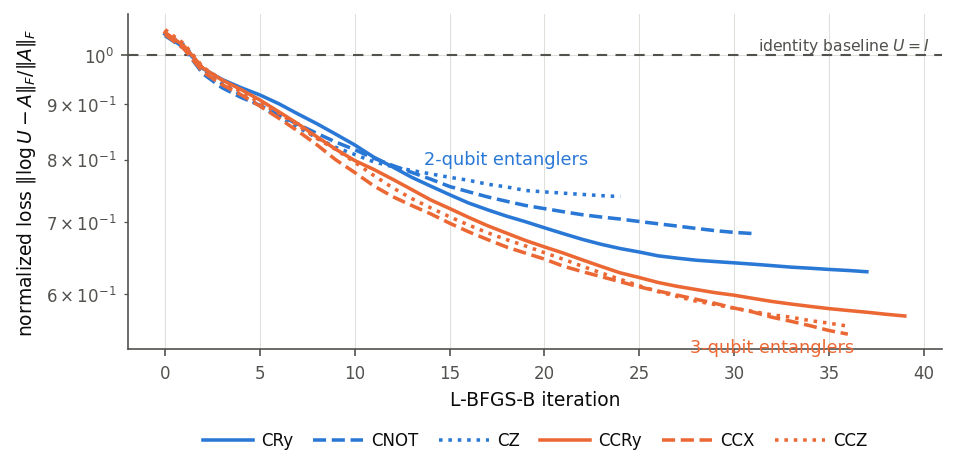

wrote fig_convergence.pdf


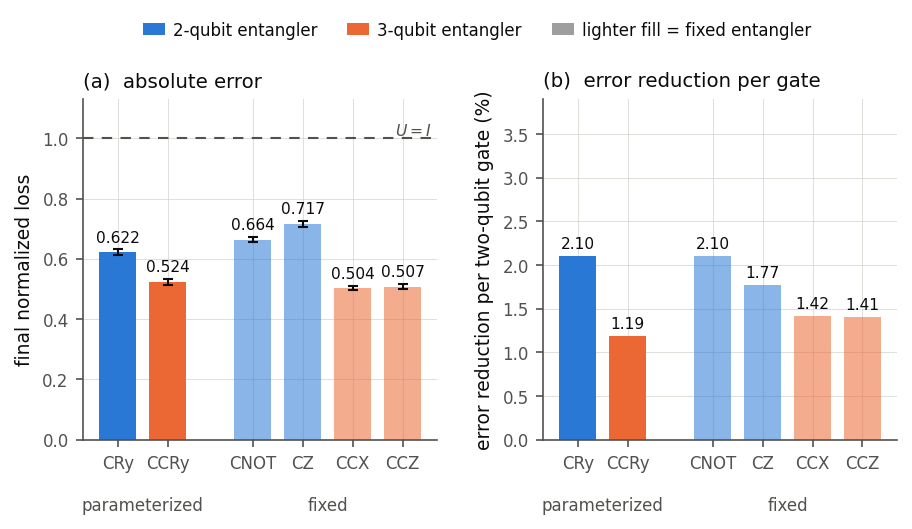

wrote fig_results.pdf


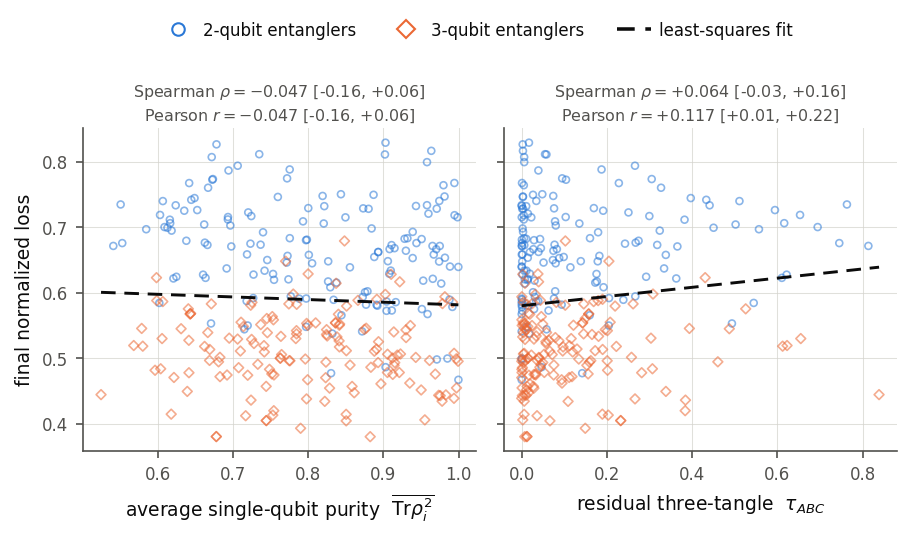

wrote fig_decoupling.pdf


In [16]:
for f in ALL_FIGURES:
    print("wrote", f(META, RES, CFG))

---
## Reading the result

* **Arity dominates.** Moving from `CRy` to `CCRy` lowers the normalized loss
  by $0.098$ ($d_z \approx 1.2$), and every three-qubit arm beats every two-qubit
  arm.
* **A trainable angle helps only for two-qubit entanglers.** `CRy` beats fixed
  `CNOT` by $0.042$ and `CZ` by $0.095$, but `CCRy` is no better than `CCX`
  (difference $+0.020$, interval includes zero).
* **`CCX` vs `CCZ` is a null** ($p \approx 0.7$), so bit-flip versus phase
  action is not what is doing the work.
* **Entanglement does not explain the ranking.** Within each target, arms that
  generate more entanglement do not reach lower error; no within-arm
  correlation survives Holm correction; and pooled correlations, reported with
  target-clustered intervals, are small.

**Two caveats to carry into any write-up.** First, arity and circuit resources
are *confounded* — a three-qubit entangler necessarily transpiles to more CNOTs
(35-40 vs 16-18), so this design cannot separate "three-body interaction" from
"more gates". Second, **per two-qubit gate the two-qubit entanglers are the more
efficient choice** (see the last table in section 8); the three-qubit arms buy
their accuracy at worse than linear cost, which is the NISQ-relevant conclusion.